In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("ktmaqi.csv", sep=',', header=2)
data['time'] = pd.to_datetime(data['time'])
data = data.set_index('time')

In [3]:
display(data.head())

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³)
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425


In [4]:
data.shape

(22536, 7)

In [5]:
data.describe()

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³)
count,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000
mean,17.919721,74.457112,18.673707,4.023171,5.013309,0.293815,0.305105
std,5.858300,20.121455,7.672883,2.262108,3.279604,0.105452,0.090636
min,1.300000,7.000000,-1.600000,0.000000,0.000000,0.102000,0.152000
25%,13.300000,61.000000,12.500000,2.400000,2.600000,0.207000,0.224000
50%,19.000000,79.000000,19.200000,3.600000,4.300000,0.302000,0.305000
75%,22.100000,92.000000,25.100000,5.200000,6.600000,0.401000,0.401000
max,32.600000,100.000000,35.800000,18.800000,26.800000,0.432000,0.433000


In [6]:
print("Missing values per column in the original DataFrame:")
display(data.isnull().sum())
print("Not a lot of missing values so removing a few rows wont matter")

Missing values per column in the original DataFrame:


temperature_2m (°C)                47
relative_humidity_2m (%)           47
apparent_temperature (°C)          47
wind_speed_10m (km/h)              47
wind_speed_100m (km/h)             47
soil_moisture_0_to_7cm (m³/m³)     47
soil_moisture_7_to_28cm (m³/m³)    47
dtype: int64

Not a lot of missing values so removing a few rows wont matter


In [7]:
#data_filled = data.fillna(method='ffill')
#print("Number of missing values after forward-fill:")
#display(data_filled.isnull().sum())
#Doesnt work

In [8]:
data = data.dropna()

In [9]:
data

,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),wind_speed_10m (km/h),wind_speed_100m (km/h),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³)
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425
...,...,...,...,...,...,...,...
2025-02-26 20:00:00,10.6,89.0,10.0,2.0,0.6,0.261,0.280
2025-02-26 21:00:00,10.3,90.0,9.7,1.6,1.3,0.261,0.280
2025-02-26 22:00:00,10.2,90.0,9.3,3.6,4.4,0.261,0.280


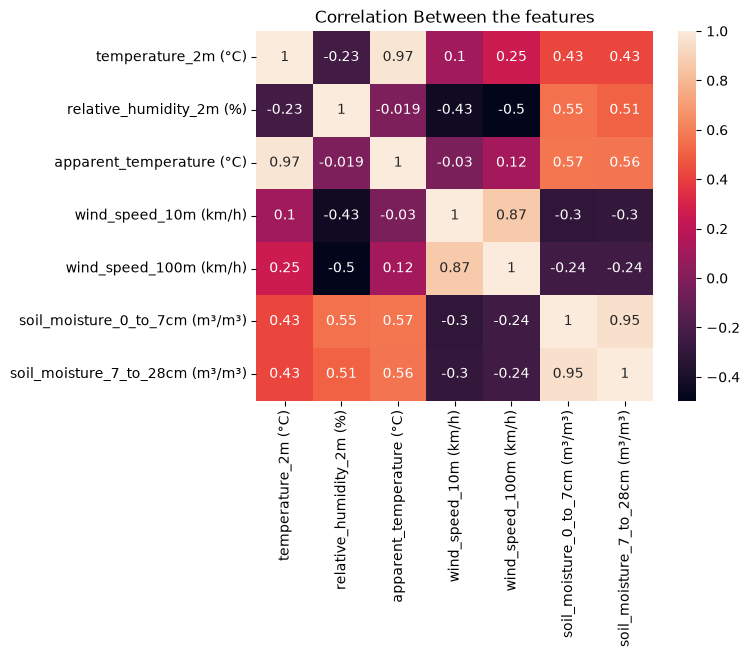

In [10]:
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Between the features")
plt.Figure(figsize=(16,10))
plt.show()

Visualize Key Environment Metrics overtime

In [11]:
#Rename these columns
new_column_names = {
    'temperature_2m (°C)': 'temperature_2m',
    'relative_humidity_2m (%)': 'humidity_2m',
    'apparent_temperature (°C)': 'apparent_temperature',
    'wind_speed_10m (km/h)': 'wind_speed_10m',
    'wind_speed_100m (km/h)': 'wind_speed_100m',
    'soil_moisture_0_to_7cm (m³/m³)': 'soil_moisture_0to7',
    'soil_moisture_7_to_28cm (m³/m³)': 'soil_moisture_7to28'
}
data = data.rename(columns=new_column_names)

print("Columns renamed successfully!")
display(data.head())

Columns renamed successfully!


,temperature_2m,humidity_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,soil_moisture_0to7,soil_moisture_7to28
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425


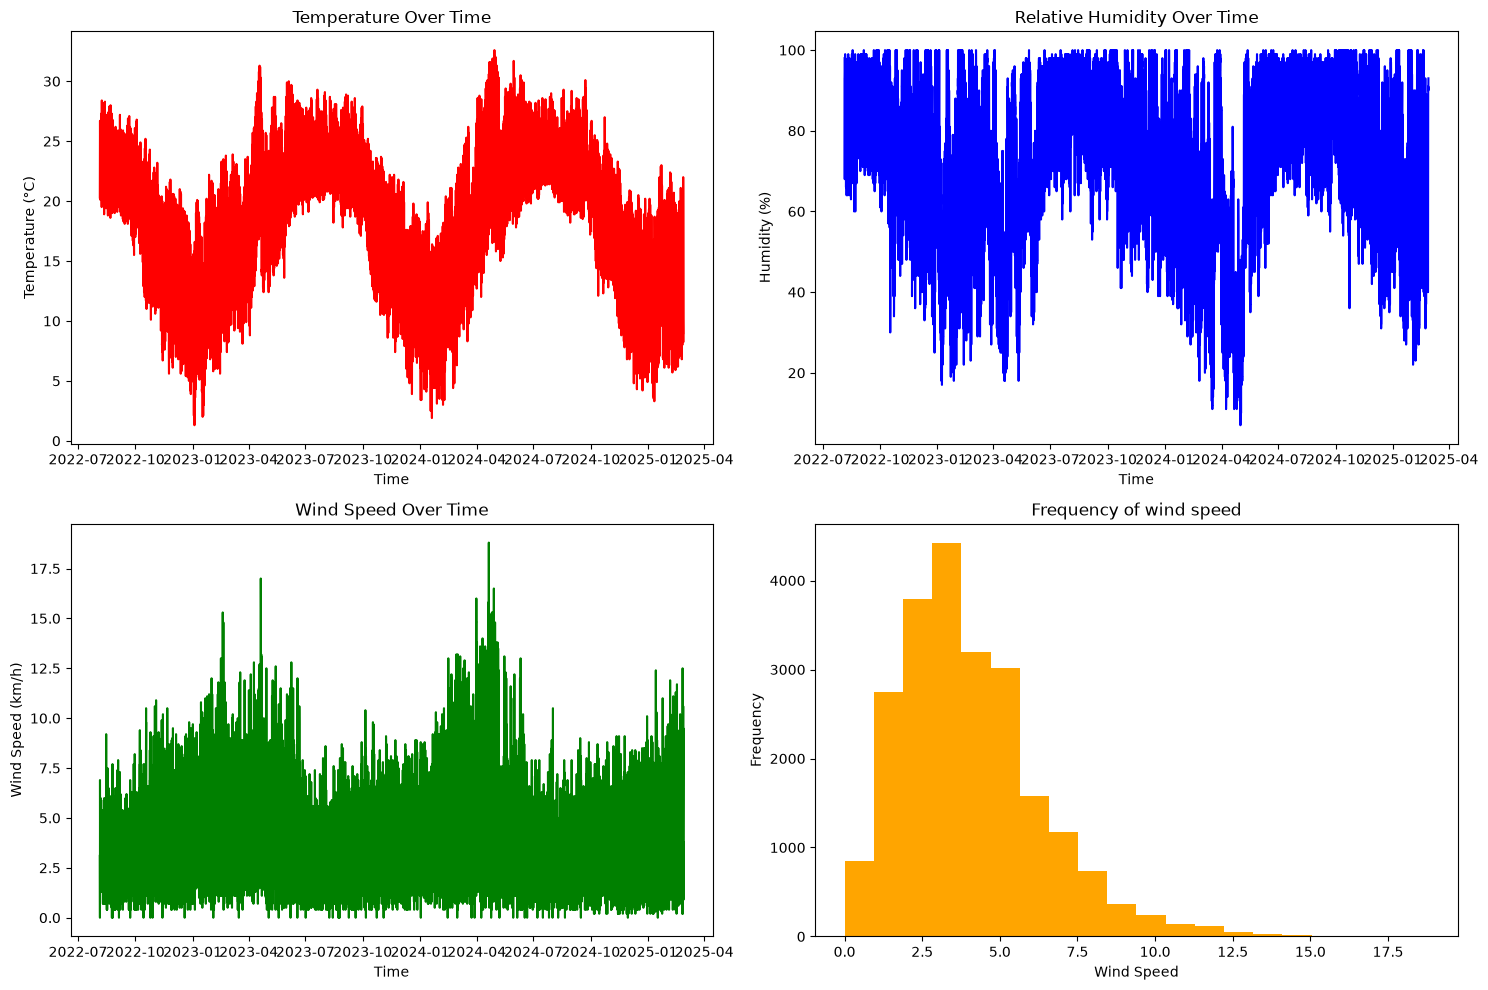

In [12]:
fig , axes = plt.subplots(nrows=2,ncols=2,figsize=(15,10))

axes[0, 0].plot(data.index, data['temperature_2m'],c="red")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].set_title("Temperature Over Time")

axes[0, 1].plot(data.index, data['humidity_2m'],c="blue")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Humidity (%)")
axes[0, 1].set_title("Relative Humidity Over Time")

axes[1, 0].plot(data.index , data["wind_speed_10m"],c="green")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Wind Speed (km/h)")
axes[1, 0].set_title("Wind Speed Over Time")

axes[1, 1].hist(data['wind_speed_10m'], bins=20, color='orange')
axes[1, 1].set_xlabel("Wind Speed")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Frequency of wind speed")

plt.tight_layout()
plt.show()

The time series plots show the general trends and fluctuations of temperature, humidity, and wind speed over the entire dataset period. We can observe daily and seasonal patterns, for instance, warmer temperatures and lower humidity during certain parts of the day or year, and variations in wind activity.

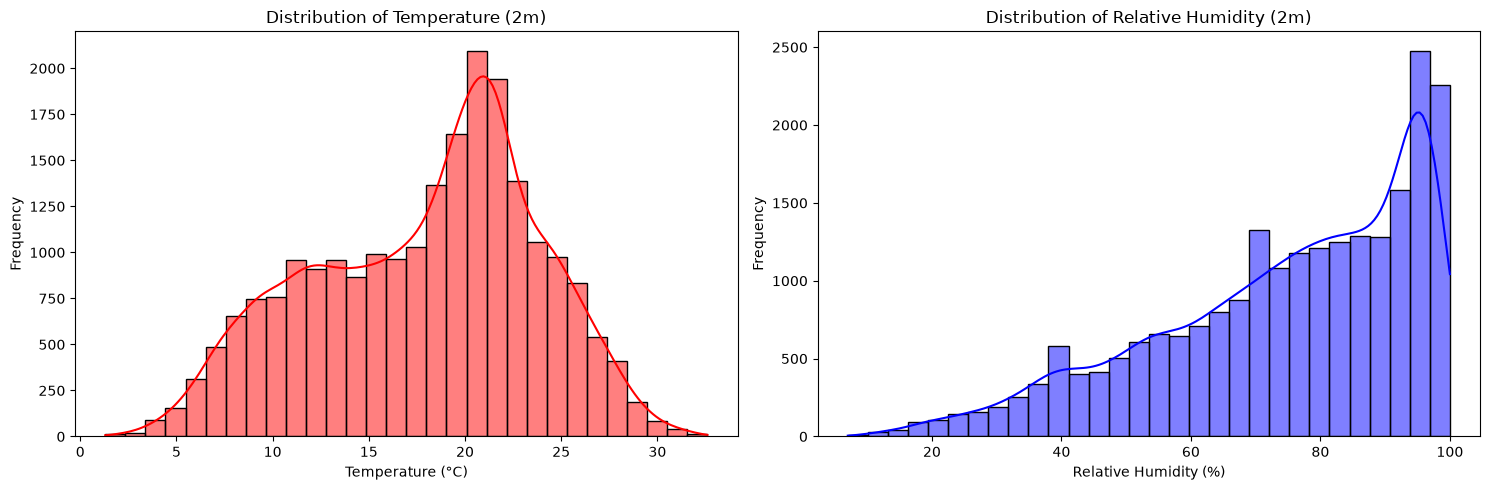

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Histogram for temperature_2m
sns.histplot(data['temperature_2m'], bins=30, kde=True, ax=axes[0], color='red')
axes[0].set_title('Distribution of Temperature (2m)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

# Histogram for humidity_2m
sns.histplot(data['humidity_2m'], bins=30, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Distribution of Relative Humidity (2m)')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The histograms with KDE (Kernel Density Estimate) provide a clear picture of how frequently different temperature and humidity values occur. For example, we might see that temperatures tend to cluster around a certain average, or that humidity is often high

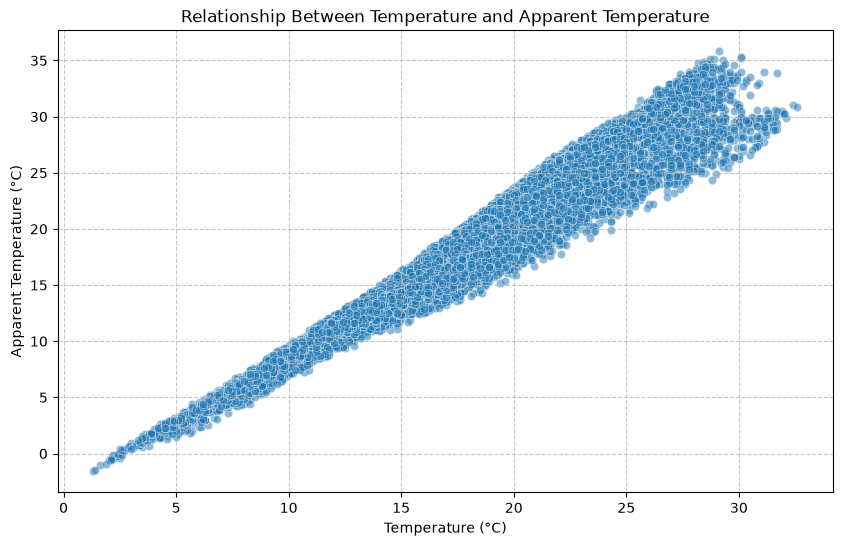

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature_2m', y='apparent_temperature', data=data, alpha=0.5)
plt.title('Relationship Between Temperature and Apparent Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Apparent Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot for temperature_2m and apparent_temperature helps us understand how closely these two metrics are related. We would typically expect a strong positive correlation, indicating that as actual temperature increases, the 'felt' temperature also increases, perhaps with some deviation due to humidity or wind.

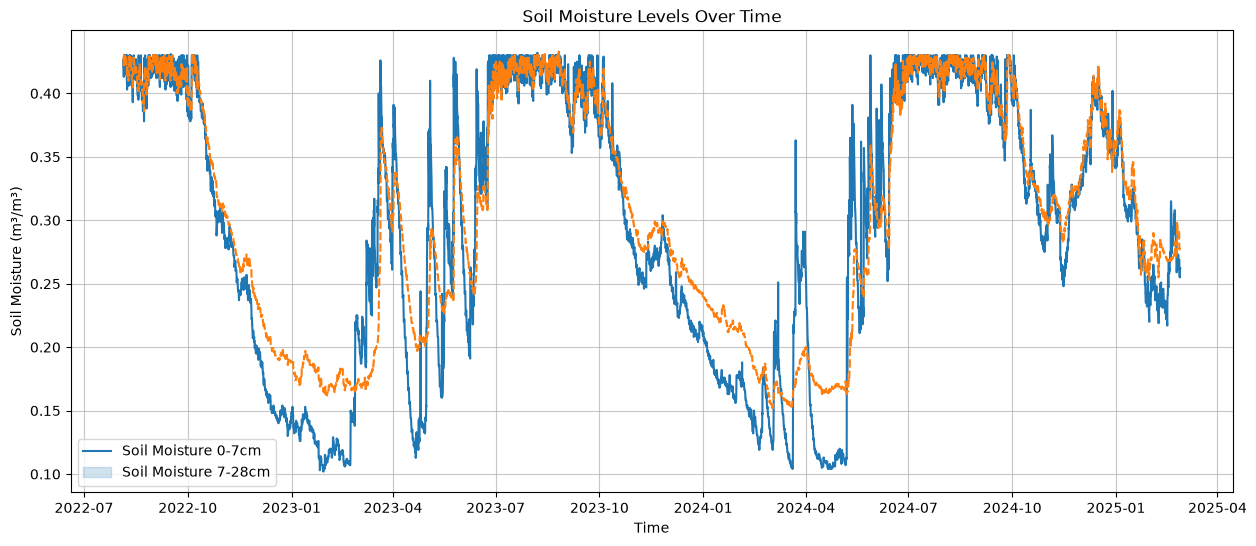

In [15]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=data[['soil_moisture_0to7', 'soil_moisture_7to28']])
plt.title('Soil Moisture Levels Over Time')
plt.xlabel('Time')
plt.ylabel('Soil Moisture (m³/m³)')
plt.legend(['Soil Moisture 0-7cm', 'Soil Moisture 7-28cm'])
plt.grid(True, alpha=0.7)
plt.show()

The time series for soil_moisture_0to7cm/m3 and soil_moisture_7to28cm_m3 allows us to track changes in soil wetness at different depths. This can reveal how quickly the topsoil dries out or absorbs moisture compared to deeper layers, and how overall soil moisture fluctuates with rainfall or dry spells.

## Model 0 - Baseline Model

In [16]:
y_true_0 = data['temperature_2m'].iloc[1:]
y_pred_0 = data['temperature_2m'].shift(1).iloc[1:] 

## Model 1 - LSTM Model

In [17]:
import torch
from torch import nn
from torch.utils.data import Dataset , DataLoader

In [18]:
#SET UP RANDOM SEED
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [19]:
#Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [20]:
data

,temperature_2m,humidity_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,soil_moisture_0to7,soil_moisture_7to28
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425
...,...,...,...,...,...,...,...
2025-02-26 20:00:00,10.6,89.0,10.0,2.0,0.6,0.261,0.280
2025-02-26 21:00:00,10.3,90.0,9.7,1.6,1.3,0.261,0.280
2025-02-26 22:00:00,10.2,90.0,9.3,3.6,4.4,0.261,0.280


In [21]:
features = data[[ "temperature_2m","humidity_2m","apparent_temperature","wind_speed_10m","wind_speed_100m","soil_moisture_0to7","soil_moisture_7to28"]]
features

,temperature_2m,humidity_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,soil_moisture_0to7,soil_moisture_7to28
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425
...,...,...,...,...,...,...,...
2025-02-26 20:00:00,10.6,89.0,10.0,2.0,0.6,0.261,0.280
2025-02-26 21:00:00,10.3,90.0,9.7,1.6,1.3,0.261,0.280
2025-02-26 22:00:00,10.2,90.0,9.3,3.6,4.4,0.261,0.280


In [22]:
features_values = features.values


In [23]:
features_values.dtype

dtype('float64')

In [24]:
tensor_data = torch.tensor(features_values,dtype=torch.float32)
tensor_data

tensor([[20.3000, 98.0000, 23.7000,  ...,  4.4000,  0.4260,  0.4290],
        [21.0000, 96.0000, 24.8000,  ...,  3.0000,  0.4250,  0.4280],
        [21.7000, 93.0000, 25.4000,  ...,  4.4000,  0.4240,  0.4270],
        ...,
        [10.2000, 90.0000,  9.3000,  ...,  4.4000,  0.2610,  0.2800],
        [ 9.3000, 91.0000,  8.2000,  ...,  2.9000,  0.2620,  0.2800],
        [ 8.3000, 93.0000,  7.1000,  ...,  2.8000,  0.2620,  0.2800]])

In [25]:
split_idx = int(0.8 * len(tensor_data))
train_df = features.iloc[:split_idx]
test_df = features.iloc[split_idx:]

In [26]:
train_df

,temperature_2m,humidity_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,soil_moisture_0to7,soil_moisture_7to28
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425
...,...,...,...,...,...,...,...
2024-08-23 10:00:00,24.2,80.0,27.9,2.9,4.2,0.426,0.414
2024-08-23 11:00:00,24.3,78.0,28.1,1.1,1.3,0.421,0.415
2024-08-23 12:00:00,22.0,91.0,25.5,3.9,5.4,0.427,0.417


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [28]:
train_scaled

array([[ 0.32933572,  1.16777402,  0.58285335, ..., -0.20628565,
         1.2666457 ,  1.38958021],
       [ 0.44989858,  1.07041532,  0.72736421, ..., -0.62513619,
         1.25773237,  1.37914993],
       [ 0.57046143,  0.92437728,  0.80618831, ..., -0.20628565,
         1.24881904,  1.36871965],
       ...,
       [ 0.62213123,  0.82701858,  0.81932566, ...,  0.09289331,
         1.27555903,  1.26441682],
       [ 0.65657776,  0.87569793,  0.92442446, ..., -0.26612144,
         1.23990571,  1.34785908],
       [ 0.62213123,  0.92437728,  0.87187506, ...,  0.51174386,
         1.22207905,  1.3374288 ]], shape=(17991, 7))

In [29]:
print(list(features.columns))

['temperature_2m', 'humidity_2m', 'apparent_temperature', 'wind_speed_10m', 'wind_speed_100m', 'soil_moisture_0to7', 'soil_moisture_7to28']


In [30]:
from data_prep import create_sequences

X_train, y_train = create_sequences(train_scaled, target_col_index=0, seq_length=24)
X_test, y_test = create_sequences(test_scaled, target_col_index=0, seq_length=24)

In [31]:
print(list(features.columns))

['temperature_2m', 'humidity_2m', 'apparent_temperature', 'wind_speed_10m', 'wind_speed_100m', 'soil_moisture_0to7', 'soil_moisture_7to28']


In [32]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((17967, 24, 7), (17967,), (4474, 24, 7), (4474,))

In [33]:
X_train.dtype

dtype('float64')

In [34]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [35]:
X_train , y_train , X_test , y_test

(tensor([[[ 0.3293,  1.1678,  0.5829,  ..., -0.2063,  1.2666,  1.3896],
          [ 0.4499,  1.0704,  0.7274,  ..., -0.6251,  1.2577,  1.3791],
          [ 0.5705,  0.9244,  0.8062,  ..., -0.2063,  1.2488,  1.3687],
          ...,
          [ 0.3293,  1.1191,  0.5960,  ..., -0.3559,  1.3023,  1.4000],
          [ 0.2949,  1.2165,  0.5434,  ...,  0.1527,  1.3023,  1.4000],
          [ 0.3121,  1.1678,  0.5303,  ...,  0.4519,  1.2756,  1.3896]],
 
         [[ 0.4499,  1.0704,  0.7274,  ..., -0.6251,  1.2577,  1.3791],
          [ 0.5705,  0.9244,  0.8062,  ..., -0.2063,  1.2488,  1.3687],
          [ 0.8288,  0.5836,  1.0164,  ..., -0.3260,  1.2399,  1.3583],
          ...,
          [ 0.2949,  1.2165,  0.5434,  ...,  0.1527,  1.3023,  1.4000],
          [ 0.3121,  1.1678,  0.5303,  ...,  0.4519,  1.2756,  1.3896],
          [ 0.3638,  1.0217,  0.5829,  ..., -0.1165,  1.2845,  1.3791]],
 
         [[ 0.5705,  0.9244,  0.8062,  ..., -0.2063,  1.2488,  1.3687],
          [ 0.8288,  0.5836,

In [36]:
from model import LSTM 
from engine import fit

In [37]:
model_1 = LSTM(input_size=7, hidden_size=128, num_stacked_layers=4).to(device)
model_1

LSTM(
  (lstm): LSTM(7, 128, num_layers=4, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [38]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train.unsqueeze(1))
test_dataset = TensorDataset(X_test, y_test.unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [40]:
train_losses, val_losses = fit(
    model_1, train_loader, test_loader,
    optimizer, loss_function, device,
    epochs=25
)

Epoch 1 | Train Loss: 0.0963
Epoch 1 | Val Loss:   0.0242
----------------------------------------
Epoch 2 | Train Loss: 0.0164
Epoch 2 | Val Loss:   0.0122
----------------------------------------
Epoch 3 | Train Loss: 0.0149
Epoch 3 | Val Loss:   0.0244
----------------------------------------
Epoch 4 | Train Loss: 0.0147
Epoch 4 | Val Loss:   0.0079
----------------------------------------
Epoch 5 | Train Loss: 0.0134
Epoch 5 | Val Loss:   0.0117
----------------------------------------
Epoch 6 | Train Loss: 0.0135
Epoch 6 | Val Loss:   0.0107
----------------------------------------
Epoch 7 | Train Loss: 0.0131
Epoch 7 | Val Loss:   0.0121
----------------------------------------
Epoch 8 | Train Loss: 0.0130
Epoch 8 | Val Loss:   0.0094
----------------------------------------
Epoch 9 | Train Loss: 0.0125
Epoch 9 | Val Loss:   0.0120
----------------------------------------
Epoch 10 | Train Loss: 0.0120
Epoch 10 | Val Loss:   0.0121
----------------------------------------
Epoch 11

C:\Users\Acer\AppData\Local\Temp\ipykernel_16484\1996344825.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


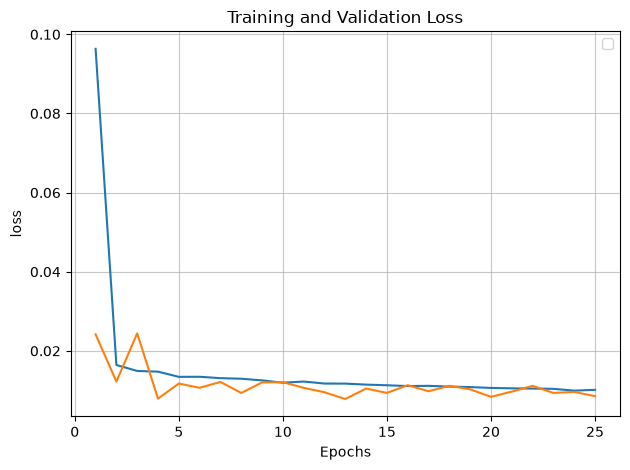

In [41]:
epochs = range(1, len(train_losses)+1)
plt.plot(epochs,train_losses)
plt.plot(epochs,val_losses)
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.grid(True,alpha=0.7)
plt.tight_layout()
plt.legend()

In [42]:
print(model_1)

LSTM(
  (lstm): LSTM(7, 128, num_layers=4, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [43]:
model_1.eval()
with torch.no_grad():
    y_pred = model_1(X_test.to(device)).cpu().numpy()

In [44]:
from inverse_transform import inverse_target

y_pred_1 = inverse_target(y_pred, scaler, n_features=7, target_idx=0)
y_test_1 = inverse_target(y_test.numpy(), scaler, n_features=7, target_idx=0)

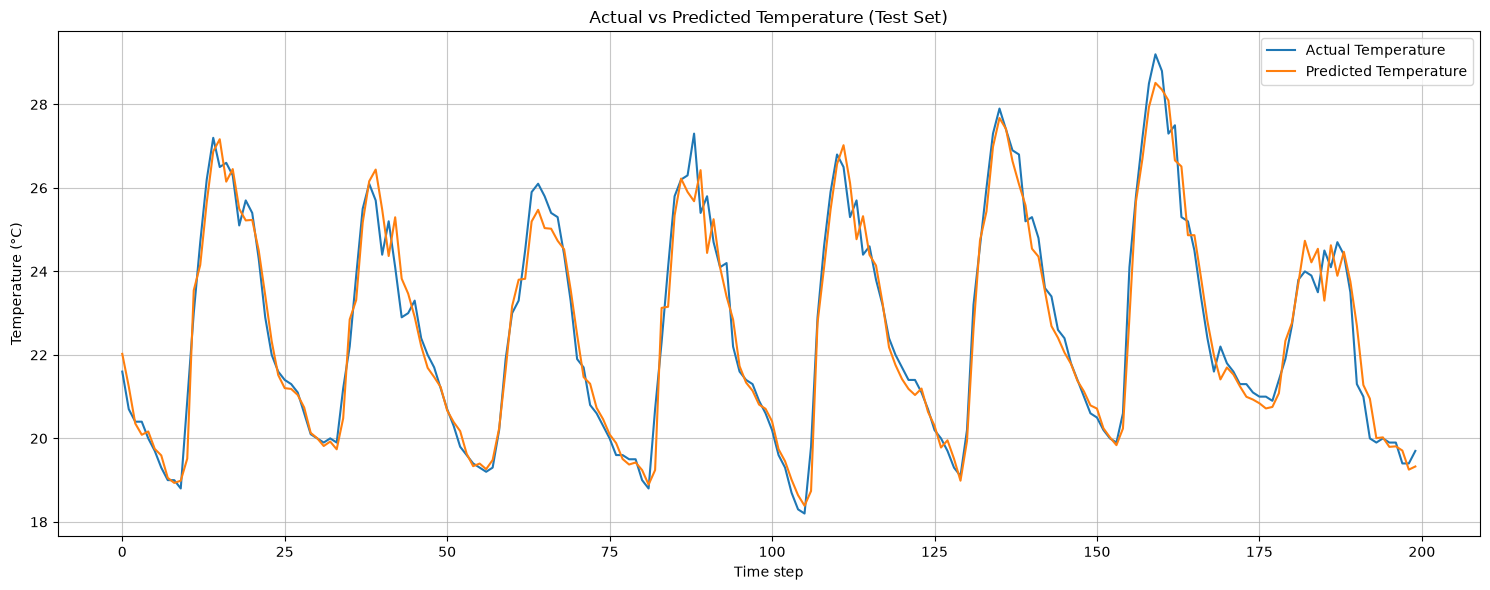

In [45]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_1[:200], label="Actual Temperature")
plt.plot(y_pred_1[:200], label="Predicted Temperature")
plt.xlabel("Time step")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature (Test Set)")
plt.legend()
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

## Model 3 - XGBoost

In [46]:
import numpy as np
from xgboost import XGBRegressor

In [47]:
data.head()

,temperature_2m,humidity_2m,apparent_temperature,wind_speed_10m,wind_speed_100m,soil_moisture_0to7,soil_moisture_7to28
time,,,,,,,
2022-08-05 00:00:00,20.3,98.0,23.7,3.1,4.4,0.426,0.429
2022-08-05 01:00:00,21.0,96.0,24.8,1.8,3.0,0.425,0.428
2022-08-05 02:00:00,21.7,93.0,25.4,3.1,4.4,0.424,0.427
2022-08-05 03:00:00,23.2,86.0,27.0,3.1,4.0,0.423,0.426
2022-08-05 04:00:00,25.1,76.0,28.9,2.1,2.6,0.421,0.425


In [48]:
data['hour'] = data.index.hour
data["hour_sin"] = np.sin(2 * np.pi * data['hour']/24)
data["hour_cos"] = np.cos(2 * np.pi * data['hour']/24)


data["day_of_year"] = data.index.day_of_year
data["doy_sin"] = np.sin(2 * np.pi * data['day_of_year']/24)
data["doy_cos"] = np.cos(2 * np.pi * data['day_of_year']/24)



In [49]:
data["Lag_1"] = data["temperature_2m"].shift(1)
data["Lag_2"] = data["temperature_2m"].shift(2)
data["Lag_3"] = data["temperature_2m"].shift(3)
data["Lag_24"] = data["temperature_2m"].shift(24)

In [50]:
data["roll_mean_3"] = data["temperature_2m"].shift(1).rolling(3).mean()
data["roll_std_3"] = data["temperature_2m"].shift(1).rolling(3).std()
data["roll_mean_24"] = data["temperature_2m"].shift(1).rolling(24).mean()

In [51]:
weather_cols = ['humidity_2m', 
                 'wind_speed_10m', 'wind_speed_100m', 
                 'soil_moisture_0to7', 'soil_moisture_7to28']

feature_cols = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_24',
                'roll_mean_3', 'roll_std_3', 'roll_mean_24',
                'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'] + weather_cols

data_model = data.dropna(subset=feature_cols + ['temperature_2m'])
X = data_model[feature_cols]
y = data_model['temperature_2m']
data_model.shape

(22465, 20)

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test_2 = train_test_split(X, y, test_size=0.25, shuffle=False)

In [53]:

model_2 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    random_state=42

)


In [54]:
model_2.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [55]:
y_pred_2 = model_2.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae0 = mean_absolute_error(y_true_0, y_pred_0)
mse0 = mean_squared_error(y_true_0, y_pred_0)
rmse0 = np.sqrt(mse0)
r2_0 = r2_score(y_true_0, y_pred_0)

mae1 = mean_absolute_error(y_test_1, y_pred_1)
mse1 = mean_squared_error(y_test_1, y_pred_1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y_test_1, y_pred_1)

mae2 = mean_absolute_error(y_test_2, y_pred_2)
mse2 = mean_squared_error(y_test_2, y_pred_2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test_2, y_pred_2)



In [57]:
model_2.feature_importances_

array([2.9794940e-01, 1.1659940e-03, 8.2119713e-03, 6.5813571e-01,
       4.7256117e-04, 1.1600015e-03, 3.4207194e-03, 1.1526269e-02,
       7.7455146e-03, 0.0000000e+00, 0.0000000e+00, 4.1182544e-03,
       1.1807590e-03, 1.5526691e-03, 1.9751792e-03, 1.3849873e-03],
      dtype=float32)

In [58]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Naive (Model 0)', 'LSTM (Model 1)', 'XGBoost (Model 2)'],
    'MAE (°C)': [mae0, mae1, mae2],
    'MSE (°C²)': [mse0, mse1, mse2],
    'RMSE (°C)': [rmse0, rmse1, rmse2],
    'R²': [r2_0, r2_1, r2_2]
})

In [59]:
results = results.round(3)
results = results.sort_values('MAE (°C)').reset_index()
results

,index,Model,MAE (°C),MSE (°C²),RMSE (°C),R²
0,1,LSTM (Model 1),0.396,0.288,0.537,0.991
1,2,XGBoost (Model 2),0.416,0.313,0.560,0.991
2,0,Naive (Model 0),0.871,1.521,1.233,0.956


### Error Analysis

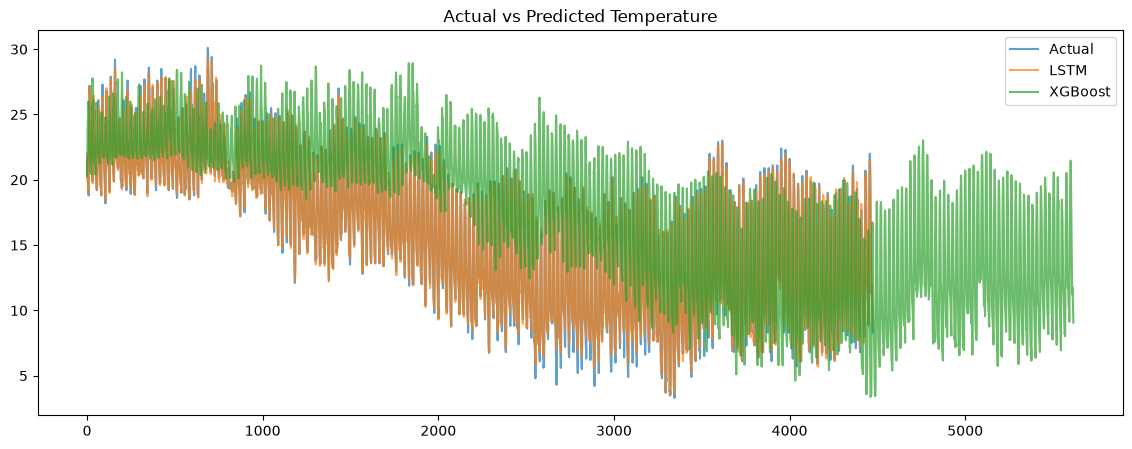

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_1, label='Actual', alpha=0.7)
plt.plot(y_pred_1, label='LSTM', alpha=0.7)
plt.plot(y_pred_2, label='XGBoost', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Temperature')
plt.show()